In [1]:
print("Hello")

Hello


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from commentator.io import (
    initialize_saraga,
    get_track,
    load_track,
    get_pitch_for_track,
    get_duration_for_track,
)

from commentator.analysis import (
    estimate_tonic,
    normalize_to_tonic,
    assign_swaras_to_contour,
    summarize_swara_distribution,
    generate_basic_swara_comment,
)

from commentator.analysis.tonic_estimator import plot_tonic_normalized_contour_snippet

from commentator.analysis.raga_baseline_knn import run_knn_leave_one_track_out

from commentator.analysis.raga_features import extract_segment_features

In [3]:
DATA_HOME = "/home/thesidpai/mir_projects/data/"
TEST_TRACK_ID = "54_Raag_Chandrakauns"

saraga = initialize_saraga(DATA_HOME)

In [4]:
track = get_track(saraga, TEST_TRACK_ID)
track

Track(
  audio_path="...handrakauns & Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.mp3.mp3",
  ctonic_path="...drakauns & Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.ctonic.txt",
  metadata_path="..., Chandrakauns & Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.json",
  phrases_path="...& Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.mphrases-manual.txt",
  pitch_path="...ndrakauns & Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.pitch.txt",
  sama_path="...uns & Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.sama-manual.txt",
  sections_path="...Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.sections-manual-p.txt",
  tempo_path="...ns & Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.tempo-manual.txt",
  track_id="54_Raag_Chand

In [5]:
duration = get_duration_for_track(TEST_TRACK_ID, saraga)
pitch_obj = get_pitch_for_track(TEST_TRACK_ID, saraga)
pitch_obj.times[:5], pitch_obj.frequencies[:5], pitch_obj.voiced_mask[:5]

(array([0.        , 0.00444444, 0.00888889, 0.01333333, 0.01777778]),
 array([0., 0., 0., 0., 0.]),
 array([False, False, False, False, False]))

In [6]:
tonic_result = estimate_tonic(pitch_obj)
tonic_result["tonic_hz"], tonic_result["track_id"], tonic_result["n_voiced_used"]

normalized_result = normalize_to_tonic(pitch_obj, tonic_result)
normalized_result["track_id"], normalized_result["tonic_hz"]

('54_Raag_Chandrakauns', 139.7973348693065)

In [7]:
swara_assignment = assign_swaras_to_contour(normalized_result)
swara_summary = summarize_swara_distribution(swara_assignment)
comment = generate_basic_swara_comment(tonic_result, swara_summary)

comment

'For 54_Raag_Chandrakauns, the estimated tonic is 139.80 Hz. After tonic normalization, the contour shows strongest occupancy near Sa, Ni and Ma. About 76.0% of voiced frames (30291 frames) were confidently assigned to canonical swara regions.'

In [8]:
swara_summary["dominant_swaras"], swara_summary["confident_ratio"], swara_summary["n_confident_frames"]

(['Sa', 'Ni', 'Ma'], 0.7596870062448273, 30291)

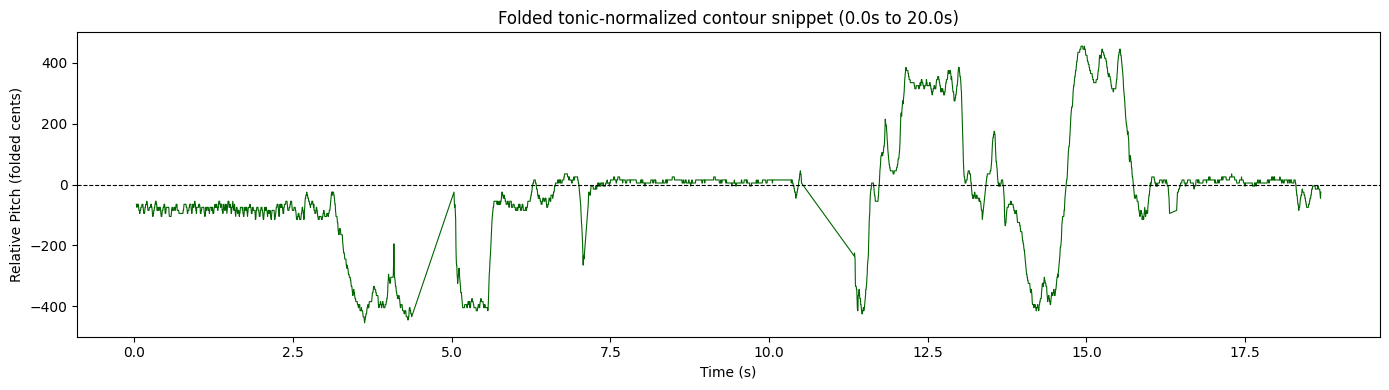

In [9]:
plot_tonic_normalized_contour_snippet(
    normalized_result,
    start_sec=0.0,
    end_sec=20.0,
    folded=True,
)

In [10]:
TRACKS = [
    {"track_id": "27_Raag_Bihag", "raga_label": "Bihag"},
    {"track_id": "81_Raag_Bihag", "raga_label": "Bihag"},
    {"track_id": "8_Raag_Kedar", "raga_label": "Kedar"},
    {"track_id": "84_Raag_Kedar", "raga_label": "Kedar"},
    {"track_id": "83_Raag_Bhoopali", "raga_label": "Bhoopali"},
    {"track_id": "105_Raag_Bhoopali", "raga_label": "Bhoopali"},
]

In [11]:
import numpy as np

from commentator.io import (
    initialize_saraga,
    get_pitch_for_track,
    get_duration_for_track,
)

from commentator.analysis.raga_features import (
    extract_segment_features,
)
from commentator.analysis.raga_baseline_knn import (
    build_segments_for_track,
    build_feature_dataset,
    run_knn_leave_one_track_out,
)

In [12]:

def pitch_fn(track_id):
    return get_pitch_for_track(track_id, saraga)

def duration_fn(track_id):
    return get_duration_for_track(track_id, saraga)

In [13]:
test_track_id = "27_Raag_Bihag"
duration = duration_fn(test_track_id)
segments = build_segments_for_track(duration, segment_length=60.0, hop=60.0)

duration, segments[:5], len(segments)

(3989.76,
 [(0.0, 60.0), (60.0, 120.0), (120.0, 180.0), (180.0, 240.0), (240.0, 300.0)],
 66)

In [14]:
pitch_obj = pitch_fn(test_track_id)
features, meta = extract_segment_features(
    pitch_obj,
    start_time=segments[0][0],
    end_time=segments[0][1],
)

features.shape, meta["track_id"], meta["start_time"], meta["end_time"]

((36,), '27_Raag_Bihag', 0.0, 60.0)

In [15]:
meta["tonic_result"]["tonic_hz"], meta["swara_summary"]["dominant_swaras"]

(291.13134764928645, ['Sa', 'Ga', 'Ni'])

In [16]:
X, y, segment_track_ids = build_feature_dataset(
    TRACKS,
    get_pitch_fn=pitch_fn,
    get_duration_fn=duration_fn,
    segment_length=60.0,
    hop=60.0,
)

X.shape, y.shape, segment_track_ids.shape

((300, 36), (300,), (300,))

In [17]:
np.unique(y, return_counts=True)

(array(['Bhoopali', 'Bihag', 'Kedar'], dtype=object), array([105, 107,  88]))

In [18]:
results = run_knn_leave_one_track_out(
    TRACKS,
    get_pitch_fn=pitch_fn,
    get_duration_fn=duration_fn,
    segment_length=60.0,
    hop=60.0,
    n_neighbors=3,
)

results["track_accuracy"], results["n_tracks"]

(1.0, 6)

In [19]:
results["track_results"]

[{'track_id': '27_Raag_Bihag',
  'true_label': 'Bihag',
  'predicted_label': 'Bihag',
  'segment_predictions': array(['Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag',
         'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag',
         'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bhoopali',
         'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag',
         'Bihag', 'Bihag', 'Kedar', 'Bihag', 'Bihag', 'Bihag', 'Bihag',
         'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag',
         'Bihag', 'Bihag', 'Bihag', 'Kedar', 'Bihag', 'Bihag', 'Bihag',
         'Bihag', 'Bihag', 'Bihag', 'Kedar', 'Bihag', 'Kedar', 'Bihag',
         'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Kedar',
         'Kedar', 'Bihag', 'Kedar'], dtype=object),
  'segment_true_labels': array(['Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag',
         'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag', 'Bihag',
         'Bihag', 'Bi

In [20]:
for r in results["track_results"]:
    print(r["track_id"], ":", r["true_label"], "->", r["predicted_label"])

27_Raag_Bihag : Bihag -> Bihag
81_Raag_Bihag : Bihag -> Bihag
8_Raag_Kedar : Kedar -> Kedar
84_Raag_Kedar : Kedar -> Kedar
83_Raag_Bhoopali : Bhoopali -> Bhoopali
105_Raag_Bhoopali : Bhoopali -> Bhoopali
